In [48]:
import polars as pl
import arviz as az
import pymc as pm
import matplotlib.pyplot as plt, numpy as np, xarray as xr

# Load the data
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/Laffer.csv", separator=";")

<Axes: xlabel='tax_rate', ylabel='tax_revenue'>

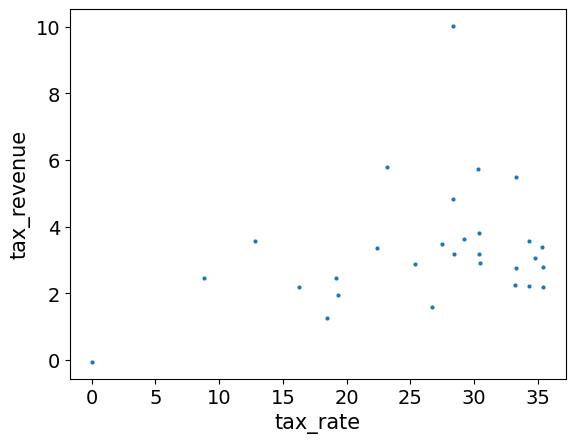

In [49]:
az.plot_pair(df.to_dict(), )

In [70]:
# model definition
with pm.Model() as basic_model:
    # priors
    alpha = pm.Normal('alpha', df["tax_revenue"].mean(), 1)
    beta = pm.Normal('beta', 0.1, 0.05)
    sigma = pm.Exponential('sigma', 1)

    mu = alpha + beta*df["tax_rate"].to_numpy()
    tax_revenue = pm.StudentT('tax_revenue', nu=4, mu=mu, sigma=sigma, observed=df["tax_revenue"].to_numpy())

    # check prior predictive
    basic_prior_predictive = pm.sample_prior_predictive(draws=500)

    # compute posterior
    basic_posterior_distribution = pm.sample(draws=1000)

# model definition
with pm.Model() as quadratic_model:
    # priors
    alpha = pm.Normal('alpha', df["tax_revenue"].mean(), 1)
    beta_1 = pm.Normal('beta_1', 0.1, 0.05)
    beta_2 = pm.Normal('beta_2', 0.005, 0.1)
    sigma = pm.Exponential('sigma', 1)

    mu = alpha + beta_1*df["tax_rate"].to_numpy() + beta_2*((df["tax_rate"]**2).to_numpy())
    tax_revenue = pm.Normal('tax_revenue', mu, sigma, observed=df["tax_revenue"].to_numpy())

    # check prior predictive
    quadratic_prior_predictive = pm.sample_prior_predictive(draws=500)

    # compute posterior
    quadratic_posterior_distribution = pm.sample(draws=1000)


Sampling: [alpha, beta, sigma, tax_revenue]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [alpha, beta_1, beta_2, sigma, tax_revenue]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_1, beta_2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Text(0.5, 1.0, 'Prior predictive checks -- Weakly regularizing priors')

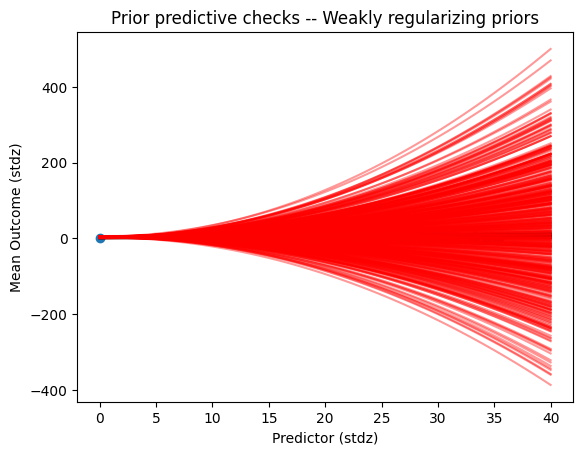

In [73]:
_, ax = plt.subplots()

x = xr.DataArray(np.linspace(0, 40, 80), dims=["plot_dim"])
y = basic_prior_predictive.prior["alpha"] + basic_prior_predictive.prior["beta"] * x
y_2 = quadratic_prior_predictive.prior["alpha"] + quadratic_prior_predictive.prior["beta_1"] * x + quadratic_prior_predictive.prior["beta_2"] * (x**2)

ax.plot(x, y.stack(sample=("chain", "draw")), c="k", alpha=0.4)
ax.plot(x, y_2.stack(sample=("chain", "draw")), c="r", alpha=0.4)
ax.scatter(df["tax_rate"].to_numpy(), df["tax_revenue"].to_numpy())

ax.set_xlabel("Predictor (stdz)")
ax.set_ylabel("Mean Outcome (stdz)")
ax.set_title("Prior predictive checks -- Weakly regularizing priors")

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta_1'}>,
        <Axes: title={'center': 'beta_1'}>],
       [<Axes: title={'center': 'beta_2'}>,
        <Axes: title={'center': 'beta_2'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

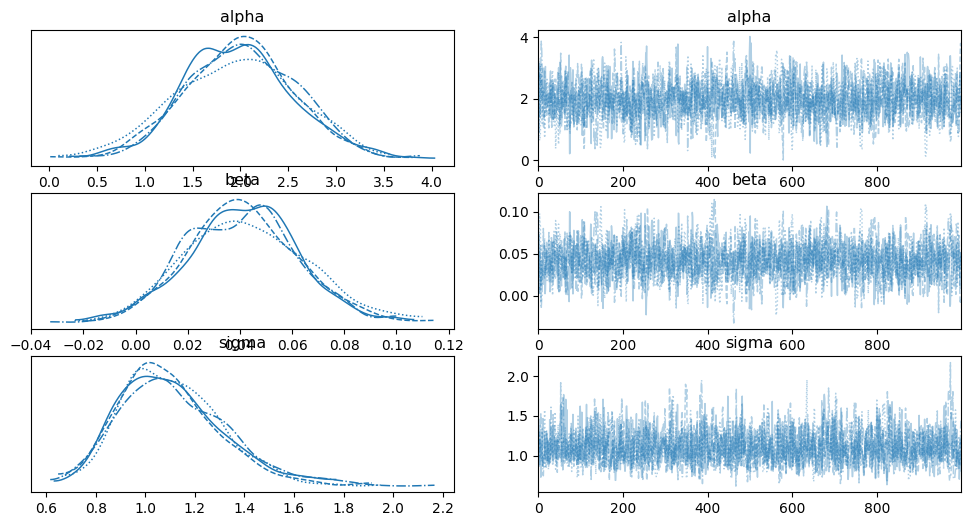

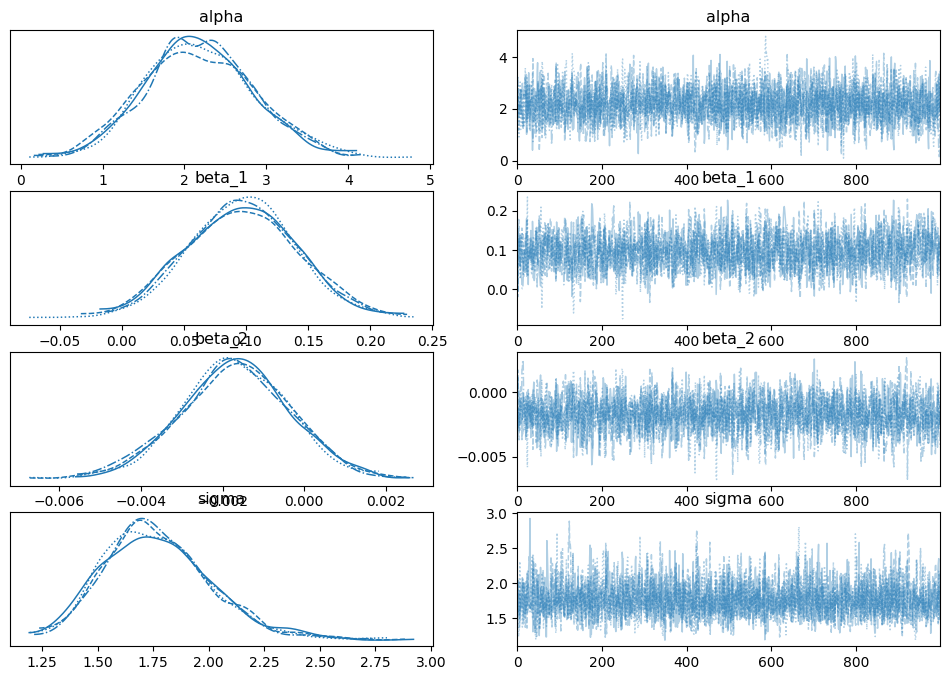

In [74]:
az.plot_trace(basic_posterior_distribution["posterior"])
az.plot_trace(quadratic_posterior_distribution["posterior"])

Sampling: [tax_revenue]


Output()

Sampling: [tax_revenue]


Output()

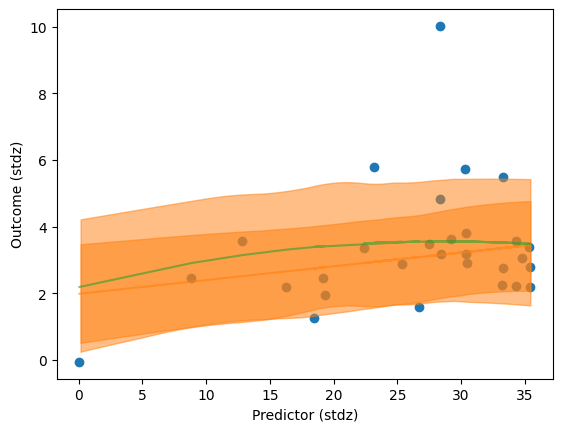

In [83]:
with basic_model:
    pm.sample_posterior_predictive(basic_posterior_distribution, extend_inferencedata=True)

with quadratic_model:
    pm.sample_posterior_predictive(quadratic_posterior_distribution, extend_inferencedata=True)

x = xr.DataArray(df["tax_rate"].to_numpy(), dims=["obs_id"])
mu_pp_basic = basic_posterior_distribution.posterior["alpha"] + basic_posterior_distribution.posterior["beta"] * x
mu_pp_quad = quadratic_posterior_distribution.posterior["alpha"] + quadratic_posterior_distribution.posterior["beta_1"] * x + quadratic_posterior_distribution.posterior["beta_2"] * (x**2)

_, ax = plt.subplots()

ax.plot(
    df["tax_rate"].to_numpy(), mu_pp_basic.mean(("chain", "draw")), label="Mean outcome", color="C1", alpha=0.6
)
ax.plot(
    df["tax_rate"].to_numpy(), mu_pp_quad.mean(("chain", "draw")), label="Mean outcome", color="C2", alpha=0.6
)
ax.scatter(df["tax_rate"].to_numpy(), idata_posterior.observed_data["tax_revenue"])
az.plot_hdi(df["tax_rate"].to_numpy(), basic_posterior_distribution.posterior_predictive["tax_revenue"], hdi_prob=0.7)
az.plot_hdi(df["tax_rate"].to_numpy(), quadratic_posterior_distribution.posterior_predictive["tax_revenue"], hdi_prob=0.7)

ax.set_xlabel("Predictor (stdz)")
ax.set_ylabel("Outcome (stdz)");

In [ ]:
with basic_model:
    pm.compute_log_likelihood(basic_posterior_distribution)

with quadratic_model:
    pm.compute_log_likelihood(quadratic_posterior_distribution)

In [79]:
az.compare({"linear_model": basic_posterior_distribution, "quadratic_model": quadratic_posterior_distribution}, scale="deviance", ic="waic")

/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
linear_model,0,109.197882,2.974428,0.000000,0.978203,13.459352,0.000000,True,deviance
quadratic_model,1,121.535007,4.922232,12.337126,0.021797,18.162709,8.411075,True,deviance
